In [19]:
import numpy as np
import sympy as smp
import qiskit 
from qiskit.circuit import QuantumRegister, QuantumCircuit, Parameter
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.primitives import StatevectorEstimator, StatevectorSampler

from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt

from functools import reduce

import pandas as pd

import scipy.optimize as opt

In [20]:
n_qubits = 10
zeta = 0
eta = 0
J = 0.1

I2 = np.eye(2)
I = np.eye(2**n_qubits)

X = np.array([
    [0, 1], 
    [1, 0]
])
Z = np.array([
    [1, 0],
    [0, -1]
])
H = np.array([
    [1, 1],
    [1, -1]
]) / np.sqrt(2)

def GateJ(n=n_qubits, j=0, gate=X):
    curr = I2 if j != 0 else gate
    # print(curr)
    for qubit in range(1, n):
        # if qubit==0: continue;
        # print(f"qubit: {qubit}")
        
        if qubit == j:
            curr = np.kron(gate, curr)
            # print('kron X')
            continue
        curr = np.kron(I2, curr)
        # print('kron I')

    return curr

GateJ(n_qubits, 7, H).shape == (1024,1024)

True

$A = \frac{1}{\zeta} ( \sum_{j=1}^{n} X_j + J \sum_{j=1}^{n-1} Z_j Z_{j+1} + \eta I)$

$| b \rangle = H^{\otimes n} | 0 \rangle$

In [21]:
# calculate first two terms of A (no zeta or eta)
Xsum = np.zeros(shape=(2**n_qubits, 2**n_qubits))
Zsum = np.zeros(shape=(2**n_qubits, 2**n_qubits))
for j in range(0, n_qubits):
    # print(j)
    Xsum += GateJ(j=j)

    if j != n_qubits-1:
        Zsum += GateJ(j=j, gate=Z) @ GateJ(j=j+1, gate=Z)

Zsum *= J
M = Xsum + Zsum

eigenvals = np.linalg.eigvals(M)

In [22]:
κ = 60 # condition number for n=10 qubits

η, ζ = smp.symbols("η ζ")

λmin = min(eigenvals)
λmax = max(eigenvals)

A0 = λmin + η - (ζ / κ)
A1 = λmax + η - ζ

soln = smp.solve([A0, A1], [η, ζ])
eta = float(soln[η])
zeta = float(soln[ζ])
soln

{ζ: 20.3847680482924, η: 10.3622570912153}

In [23]:
A = (M + eta * I) / zeta
A

array([[0.55248395, 0.04905624, 0.04905624, ..., 0.        , 0.        ,
        0.        ],
       [0.04905624, 0.5426727 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.04905624, 0.        , 0.53286145, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.53286145, 0.        ,
        0.04905624],
       [0.        , 0.        , 0.        , ..., 0.        , 0.5426727 ,
        0.04905624],
       [0.        , 0.        , 0.        , ..., 0.04905624, 0.04905624,
        0.55248395]], shape=(1024, 1024))

To scale from 3->10 qubits, we need 3 layers:
* Hardware-efficient ansatz
* Layered controlled A gates
* controlled U gate ($H^{\otimes n} | 0 \rangle $)

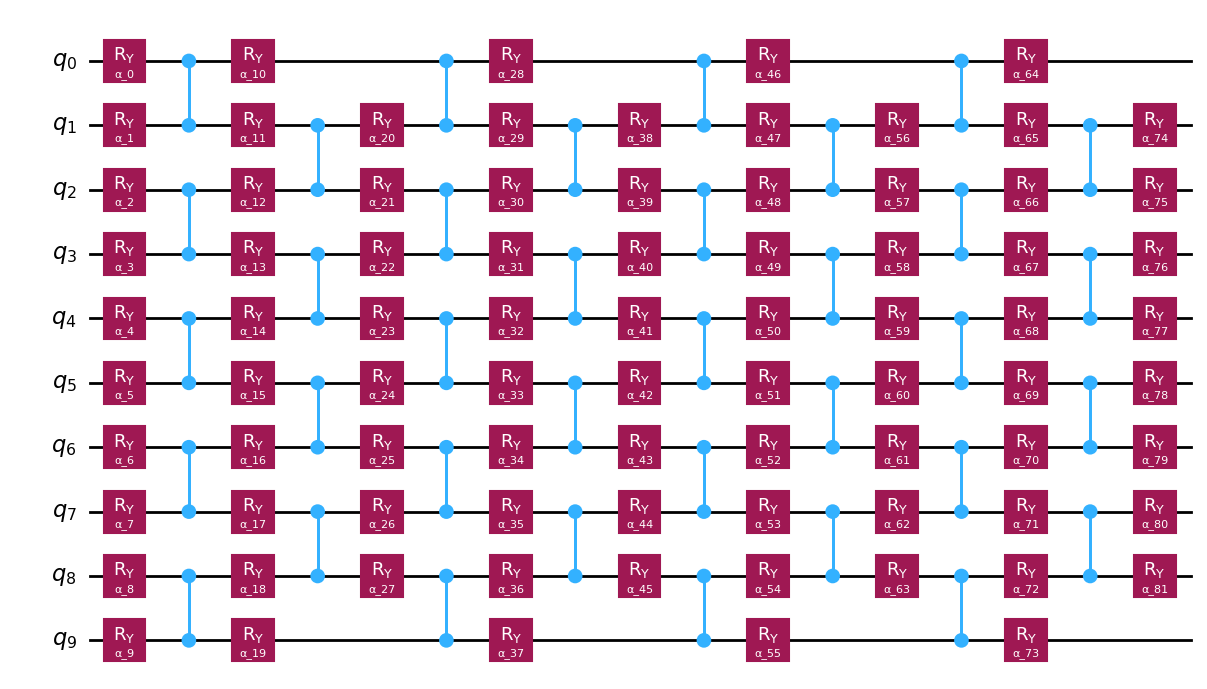

In [24]:
ancilla_idx = n_qubits

# U_b gate
Ub = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    Ub.h(i)

# ansatz

def variational_form(n_qubits: int=10, layers: int=4):
    # init rot layer
    num_params = n_qubits
    # per layer
    num_params += n_qubits * layers # per full rotational layer
    num_params += (n_qubits - 2) * layers # per alternating rotational layer

    α = [Parameter(f"α_{i}") for i in range(num_params)]

    v = QuantumCircuit(n_qubits)

    # initial rotational layer
    param = 0
    for qubit in range(n_qubits):
        v.ry(α[param], qubit) # first ten parameters
        param += 1

    for layer in range(layers):
        # entangling layer between adjacent pairs of qubits
        for qubit in range(0, n_qubits-1, 2):
            v.cz(qubit, qubit + 1)

        # v.barrier()

        # rotation layer
        for qubit in range(n_qubits):
            v.ry(α[param], qubit)
            param += 1

        # entangling layer between alternating pairs of qubits
        for qubit in range(1, n_qubits-2, 2):
            v.cz(qubit, qubit+1)

        # rotational layer for alternating pairs
        for qubit in range(1, n_qubits-1):
            v.ry(α[param], qubit)
            param += 1

    # print(param, v.num_parameters)

    return v, α

variational_form(n_qubits=10, layers=4)[0].draw('mpl')

In [25]:
# controlled A gate

def build_A_terms(l, n_qubits=10):
    coefficients = 0
    operations = []

    if l == 0:
        coefficients = eta / zeta # eta / zeta
        operations.append(("I", 0))

    if l >= 1  and l <= n_qubits:
        coefficients = 1 / zeta # 1 / zeta
        operations.append(("X", l-1)) 

    if l >= n_qubits + 1 and l <= (2 * n_qubits - 1):
        coefficients = J / zeta # J / zeta
        operations.append(("Z", l-n_qubits-1))
        operations.append(("Z", l-n_qubits))

    return coefficients, operations

All $c_l$ and $A_l$ terms, aka $A = \sum c_l A_l$

In [26]:
c = []

for l in range(2 * n_qubits - 1):
    co, _ = build_A_terms(l, n_qubits)
    c.append(co)
    print(build_A_terms(l, n_qubits))

print(c)

(0.5083333333333333, [('I', 0)])
(0.04905623638350735, [('X', 0)])
(0.04905623638350735, [('X', 1)])
(0.04905623638350735, [('X', 2)])
(0.04905623638350735, [('X', 3)])
(0.04905623638350735, [('X', 4)])
(0.04905623638350735, [('X', 5)])
(0.04905623638350735, [('X', 6)])
(0.04905623638350735, [('X', 7)])
(0.04905623638350735, [('X', 8)])
(0.04905623638350735, [('X', 9)])
(0.004905623638350735, [('Z', 0), ('Z', 1)])
(0.004905623638350735, [('Z', 1), ('Z', 2)])
(0.004905623638350735, [('Z', 2), ('Z', 3)])
(0.004905623638350735, [('Z', 3), ('Z', 4)])
(0.004905623638350735, [('Z', 4), ('Z', 5)])
(0.004905623638350735, [('Z', 5), ('Z', 6)])
(0.004905623638350735, [('Z', 6), ('Z', 7)])
(0.004905623638350735, [('Z', 7), ('Z', 8)])
[0.5083333333333333, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.04905623638350735, 0.004905623638350735, 0.004905623638

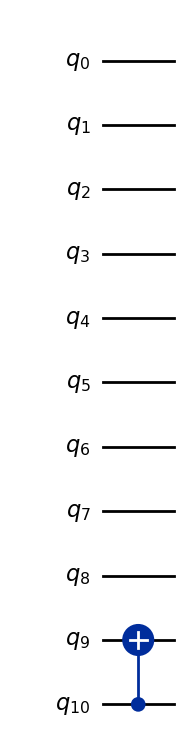

In [27]:
def controlled_A(i: int=0, n_qubits: int=10):
    A = QuantumCircuit(n_qubits + 1)

    _, ops = build_A_terms(i)
    # print(ops)
    for op, qubit in ops:
        match(op):
            case "I":
                pass
            case "X":
                A.cx(ancilla_idx, qubit)
            case "Z":
                A.cz(ancilla_idx, qubit)

    return A

controlled_A(10).draw('mpl')

In [28]:
# hadamard test
estimator = StatevectorEstimator()
V, _ = variational_form()
controlled_A_cache = [controlled_A(l) for l in range(2*n_qubits - 1)]

def local_hadamard_test(parameters: list=[], l: int=0, lp: int=0, j: int=0, part: str="real", n_qubits: int=10):
    system = QuantumRegister(n_qubits, name='q')
    ancilla = QuantumRegister(1, name='a')
    circuit = QuantumCircuit(system, ancilla)

    # first hadamard for the hadamard test
    circuit.h(ancilla_idx)

    if part.lower() == 'im':
        # phase shift by -pi/2
        θ = -np.pi / 2

        circuit.p(θ, ancilla_idx)

    # V, _ = variational_form()

    # apply ansatz
    circuit.compose(V, inplace=True)

    circuit.barrier()

    # A_l
    circuit.compose(controlled_A_cache[l], inplace=True)
    circuit.barrier()

    # typically would be the adjoint of U but U_dag = U in this case
    circuit.compose(Ub, inplace=True)
    circuit.barrier()

    if j != -1:
        circuit.cz(ancilla_idx, j)
    circuit.barrier()

    circuit.compose(Ub, inplace=True)
    circuit.barrier()

    circuit.compose(controlled_A_cache[lp], inplace=True)
    circuit.barrier()

    circuit.h(ancilla_idx)

    observables = [[SparsePauliOp(["ZIIIIIIIIII"])]]

    pub = (circuit, observables, parameters)
    job = estimator.run([pub])

    evs = job.result()[0].data.evs.squeeze()

    return evs, circuit

for l in range(2 * n_qubits - 1):
    evs, circuit = local_hadamard_test(np.zeros(82), l=l, lp=9, part='im')

    # display(circuit.draw('mpl'))
    print(f"l: {l}\nevs: {evs}")


l: 0
evs: -3.7300914504872254e-34
l: 1
evs: -3.7300914504872254e-34
l: 2
evs: -3.7300914504872254e-34
l: 3
evs: -3.6779389456346876e-34
l: 4
evs: -3.6522741142146352e-34
l: 5
evs: -1.8310894522720174e-34
l: 6
evs: -2.971945103954625e-34
l: 7
evs: -3.668666208878861e-34
l: 8
evs: -3.1598127725716734e-34
l: 9
evs: -8.77551699456539e-34
l: 10
evs: -3.4188221053968527e-34
l: 11
evs: -3.7300914504872254e-34
l: 12
evs: -3.7300914504872254e-34
l: 13
evs: -3.7300914504872254e-34
l: 14
evs: -3.7300914504872254e-34
l: 15
evs: -3.7300914504872254e-34
l: 16
evs: -3.7300914504872254e-34
l: 17
evs: -3.7300914504872254e-34
l: 18
evs: -3.7300914504872254e-34


In [29]:
# get the real and imaginary parts of μ 
def mu(weights, l: int=None, lp: int=None, j: int=None):
    mu_real = local_hadamard_test(weights, l=l, lp=lp, j=j, part='re')[0]
    mu_imag = local_hadamard_test(weights, l=l, lp=lp, j=j, part='im')[0]

    # display(circuit)

    return mu_real + 1.0j * mu_imag

In [30]:
L = 2 * n_qubits - 1

# def mu_symmetric_sum(weights, j):
#     total = 0.0 + 0.0j
#     for l in range(L):
#         for lp in range(l, L):
#             val = mu(weights, l, lp, j)
#             term_upper = c[l] * np.conj(c[lp]) * val
#             if lp == l:
#                 total += term_upper
#             else:
#                 term_lower = c[lp] * np.conj(c[l]) * np.conj(val)
#                 total += term_upper + term_lower
#     return total

# def norm(weights):
#     return abs(mu_symmetric_sum(weights, -1))

# def local_cost(weights):
#     mu_sum = 0.0 + 0.0j
#     for j in range(n_qubits):
#         mu_sum += mu_symmetric_sum(weights, j)
#     mu_sum = abs(mu_sum)
#     return float(0.5 - 0.5 * mu_sum / (n_qubits * norm(weights)))

def build_hadamard_circuit(l, lp, j):
    system = QuantumRegister(n_qubits, name='q')
    ancilla = QuantumRegister(1, name='a')
    circuit = QuantumCircuit(system, ancilla)

    circuit.h(ancilla_idx)
    circuit.compose(V, inplace=True)
    circuit.compose(controlled_A_cache[l], inplace=True)
    circuit.compose(Ub, inplace=True)

    if j != -1:
        circuit.cz(ancilla_idx, j)

    circuit.compose(Ub, inplace=True)
    circuit.compose(controlled_A_cache[lp], inplace=True)
    # no final Hadamard, no phase gate branch

    return circuit

pair_list = [(l, lp) for l in range(L) for lp in range(l, L)]
j_list = list(range(-1, n_qubits))

circuit_cache = {
    (l, lp, j): build_hadamard_circuit(l, lp, j)
    for (l, lp) in pair_list for j in j_list
}
combo_keys = list(circuit_cache.keys())

obs_x = SparsePauliOp(["X" + "I" * n_qubits])
obs_y = SparsePauliOp(["Y" + "I" * n_qubits])

def evaluate_all_mu(weights):
    pubs = [(circuit_cache[key], [obs_x, obs_y], weights) for key in combo_keys]
    result = estimator.run(pubs).result()

    mu_dict = {}
    for key, res in zip(combo_keys, result):
        re_val, im_val = np.asarray(res.data.evs).flatten()
        mu_dict[key] = re_val + 1j * im_val
    return mu_dict

def local_cost(weights):
    mu_dict = evaluate_all_mu(weights)

    def symmetric_sum(j):
        total = 0.0 + 0.0j
        for (l, lp) in pair_list:
            val = mu_dict[(l, lp, j)]
            total += c[l] * np.conj(c[lp]) * val
            if lp != l:
                total += c[lp] * np.conj(c[l]) * np.conj(val)
        return total

    norm_val = abs(symmetric_sum(-1))
    mu_sum = abs(sum(symmetric_sum(j) for j in range(n_qubits)))

    return float(0.5 - 0.5 * mu_sum / (n_qubits * norm_val))

In [31]:
# --- fast numpy-based cost evaluation ---
# Every A_l here is a single Pauli term (I, X_i, or Z_iZ_{i+1}) and U_b = H^{\otimes n},
# so mu_{l,l',j} = <phi| A_l' (U_b Z_j U_b) A_l |phi> can be computed directly on the
# 2^n-dim system statevector with index permutations / sign flips / one dense Hadamard
# matmul -- no ancilla qubit and no per-term circuit simulation needed classically.
# (Replaces the Statevector.evolve()/expectation_value() loop over 2090 tail circuits
# per cost call with a handful of numpy ops; validated to agree with the old version
# to floating-point precision, ~250x faster per call.)

N = 2 ** n_qubits
L = 2 * n_qubits - 1
c_arr = np.array(c)

idx = np.arange(N)
Hn = reduce(np.kron, [H] * n_qubits)

ops_list = [build_A_terms(l)[1] for l in range(L)]

flip_idx = {j: idx ^ (1 << j) for j in range(n_qubits)}

sign_zz = {}
for j in range(n_qubits - 1):
    bit_j = (idx >> j) & 1
    bit_j1 = (idx >> (j + 1)) & 1
    sign_zz[j] = (1.0 - 2.0 * (bit_j ^ bit_j1))

sign_z = {j: (1.0 - 2.0 * ((idx >> j) & 1)) for j in range(n_qubits)}

j_list = [-1] + list(range(n_qubits))

def apply_A_l(phi, l):
    kind, first_qubit = ops_list[l][0]
    if kind == "I":
        return phi.copy()
    if kind == "X":
        return phi[flip_idx[first_qubit]]
    return sign_zz[first_qubit] * phi  # Z_j Z_{j+1}

def local_cost(weights):
    bound = V.assign_parameters(weights)
    phi = Statevector(bound).data.real  # Ry + H + X + Z gates only -> state stays real

    Psi = np.empty((N, L))
    for l in range(L):
        Psi[:, l] = apply_A_l(phi, l)

    Chi = Hn @ Psi  # U_b applied once to every A_l|phi>

    stacked = np.empty((N, len(j_list) * L))
    for k, j in enumerate(j_list):
        stacked[:, k * L:(k + 1) * L] = Chi if j == -1 else sign_z[j][:, None] * Chi

    Chi2_all = Hn @ stacked  # U_b applied again, batched over every j

    S = np.empty(len(j_list))
    for k in range(len(j_list)):
        Chi2 = Chi2_all[:, k * L:(k + 1) * L]
        mu_matrix = Chi2.T @ Psi  # mu_matrix[l, lp] = mu_{l, lp, j}
        S[k] = c_arr @ mu_matrix @ c_arr

    norm_val = abs(S[0])
    mu_sum = abs(S[1:].sum())
    return float(0.5 - 0.5 * mu_sum / (n_qubits * norm_val))

In [32]:
np.random.seed(12873)
α = 0.001 * np.random.randn(82)
α

array([ 2.45276491e-04,  9.78517289e-04, -1.16711228e-03,  5.74930634e-04,
        1.56642690e-03, -1.77631361e-04, -1.62350856e-04,  4.38960971e-04,
       -7.39666674e-04,  1.14431884e-03, -1.49825575e-03,  1.42476803e-03,
       -6.41049776e-04, -2.32473470e-04,  1.63941206e-03,  6.21804063e-04,
       -1.63904975e-04, -6.05533315e-04,  7.44847026e-04,  1.63721143e-04,
       -2.08407603e-04,  8.69687501e-04, -1.72340797e-03, -4.26655566e-04,
        6.69905658e-05, -1.76433599e-03, -1.98520004e-03,  1.42876827e-03,
        9.85102251e-05, -1.92806182e-04, -9.34231883e-05,  3.98420207e-04,
        1.32649612e-03,  1.75125457e-04,  2.40297988e-03,  8.54854361e-04,
       -6.70829275e-04,  2.36654148e-03,  9.11793503e-04,  9.13472899e-04,
       -3.29361179e-04,  9.04253554e-04,  6.88696524e-04, -1.15844520e-04,
       -7.26620701e-04, -3.91093227e-04, -2.53724045e-04, -4.07492677e-04,
       -3.10337637e-04,  8.38650738e-04, -8.87711694e-04,  1.41130164e-04,
       -1.40248664e-03, -

Custom minimization method needed:

For the Ising-inspired 10-qubit VQLS, the authors used an optimization method where in each iteration, a random direction w is chosen in the parameter space to perform a line search along, aka solving $$min_{s \in \mathbb{R}} C(\vec{\alpha} + s \hat{w})$$

iter   0   cost = 0.00016354174138277777
iter   1   cost = 0.00016348689535600203
iter   2   cost = 0.0001633756902930661
iter   3   cost = 0.0001631414050056179
iter   4   cost = 0.00016306209640853941
iter   5   cost = 0.0001628181185338029
iter   6   cost = 0.00016280260461970508
iter   7   cost = 0.00016271176415522115
iter   8   cost = 0.00016270399530310398
iter   9   cost = 0.00016268479797321156
iter  10   cost = 0.00016249638451620863
iter  11   cost = 0.00016248436865273774
iter  12   cost = 0.0001623471637422491
iter  13   cost = 0.00016218823212404976
iter  14   cost = 0.00016218066096729267
iter  15   cost = 0.00016217239040472453
iter  16   cost = 0.00016210168455282892
iter  17   cost = 0.00016206254264461428
iter  18   cost = 0.00016197479674456838
iter  19   cost = 0.0001617795945870748
iter  20   cost = 0.00016176265526762768
iter  21   cost = 0.00016114349480977896
iter  22   cost = 0.00016113133469725094
iter  23   cost = 0.00016111637832788572
iter  24   cost = 0.0

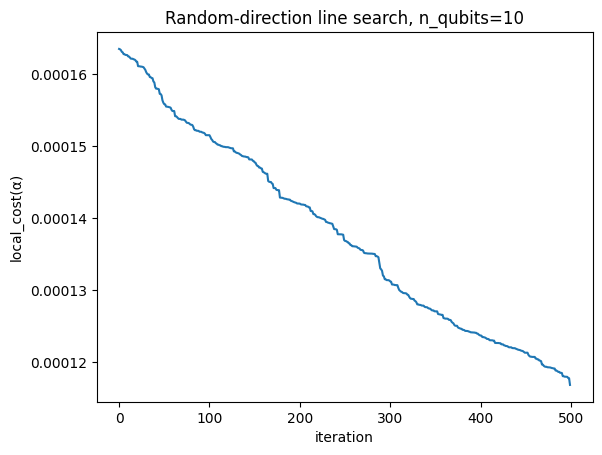

In [46]:
iterations = 500
history = []

for iter in range(iterations):
    w = np.random.randn(len(α))
    w /= np.linalg.norm(w)

    cost_bound = lambda s: local_cost(α + s * w)
    result = opt.minimize_scalar(cost_bound)

    s_new = result.x
    cost = result.fun

    α = α + s_new * w

    # cost = local_cost(α)
    history.append(cost)
    print(f"iter {iter:3d}   cost = {cost}")

plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("local_cost(α)")
plt.title(f"Random-direction line search, n_qubits={n_qubits}")
plt.show()

In [47]:
α_opt = α
display(α)

# get solution from variational form
print(f"α_optimal: {α}")

bound_circuit = V.assign_parameters(α_opt)
bound_circuit.draw('mpl')

bound_circuit.measure_all()

sampler = StatevectorSampler()
job = sampler.run([bound_circuit], shots=10_000)
result = job.result()[0]

counts = result.data.meas.get_counts()
probs = {k: v / 10_000 for k, v in counts.items()}

statevector = np.zeros(2 ** n_qubits)
for bitstr, p in probs.items():
    idx = int(bitstr, 2)
    statevector[idx] = p #np.sqrt(p)  # use the probabilites

# statevector /= np.linalg.norm(statevector)
display(probs)
display(statevector)

array([-0.26096574, -0.52235306,  1.12127522,  0.26759578,  0.98124109,
        1.36042656,  0.00426067,  0.6553479 , -0.84968271, -0.43238256,
        0.4549489 ,  0.88008645, -1.72029477,  0.10830889,  0.37386559,
       -1.43299275,  0.9253655 ,  0.09057302, -0.01582927,  1.65812015,
        0.20988288,  0.05968321, -0.04415415,  0.07671598,  1.3623591 ,
       -0.01712575,  1.2148905 ,  0.60833229, -2.02928661,  0.62695116,
        0.50410924,  1.71960253,  0.5111663 ,  0.04340262, -0.00659191,
        0.07990976, -0.06533701, -0.86537808,  0.62263134, -1.89424859,
        1.30417328,  0.94240132,  0.19015404,  1.90464284, -0.18919265,
        1.91367959, -0.06723298, -0.07355286,  0.04354764, -1.12759573,
       -1.5165148 ,  1.42229126,  0.68843522, -0.03399838,  0.27061236,
       -0.56939841,  0.82921397,  2.11528198,  0.45899911, -1.13564315,
       -0.03109814, -0.25080862, -0.36325279,  0.05282347,  0.08240105,
       -1.45308655, -0.98551114, -0.02573463, -1.19362553, -0.62

α_optimal: [-0.26096574 -0.52235306  1.12127522  0.26759578  0.98124109  1.36042656
  0.00426067  0.6553479  -0.84968271 -0.43238256  0.4549489   0.88008645
 -1.72029477  0.10830889  0.37386559 -1.43299275  0.9253655   0.09057302
 -0.01582927  1.65812015  0.20988288  0.05968321 -0.04415415  0.07671598
  1.3623591  -0.01712575  1.2148905   0.60833229 -2.02928661  0.62695116
  0.50410924  1.71960253  0.5111663   0.04340262 -0.00659191  0.07990976
 -0.06533701 -0.86537808  0.62263134 -1.89424859  1.30417328  0.94240132
  0.19015404  1.90464284 -0.18919265  1.91367959 -0.06723298 -0.07355286
  0.04354764 -1.12759573 -1.5165148   1.42229126  0.68843522 -0.03399838
  0.27061236 -0.56939841  0.82921397  2.11528198  0.45899911 -1.13564315
 -0.03109814 -0.25080862 -0.36325279  0.05282347  0.08240105 -1.45308655
 -0.98551114 -0.02573463 -1.19362553 -0.62157164 -0.05092312 -0.04268195
  0.82979201 -1.31809883  1.43297436 -2.24591497  0.63594529 -1.13203883
 -1.01614911  0.91865324 -1.55696139  0.

{'0010000101': 0.0009,
 '0111101011': 0.0009,
 '0110101110': 0.0011,
 '0011000011': 0.0009,
 '0010100111': 0.0007,
 '0000101001': 0.0012,
 '0111101000': 0.001,
 '0011110110': 0.0017,
 '0001011111': 0.0012,
 '0000100100': 0.0014,
 '1010110010': 0.0008,
 '0100010011': 0.0013,
 '0111101100': 0.0009,
 '1011000001': 0.0009,
 '0111101010': 0.0005,
 '0000101100': 0.0021,
 '0011011101': 0.001,
 '0001000111': 0.0011,
 '0010100011': 0.0017,
 '1111110101': 0.0012,
 '0011011110': 0.001,
 '0100101000': 0.0009,
 '0010011101': 0.0013,
 '0110011011': 0.0005,
 '0011010000': 0.0018,
 '1111011010': 0.0007,
 '1010000100': 0.0007,
 '1010101101': 0.0012,
 '1101101111': 0.001,
 '1010010111': 0.0011,
 '0111010101': 0.0013,
 '0101000100': 0.0009,
 '0100010111': 0.001,
 '1111101010': 0.0007,
 '1110101010': 0.0005,
 '1100010010': 0.0012,
 '1110111110': 0.001,
 '1011100110': 0.0009,
 '0000000011': 0.0006,
 '0001100110': 0.0015,
 '0100001000': 0.001,
 '1111100011': 0.0009,
 '0001001101': 0.0013,
 '1100000010': 0.0

array([0.0011, 0.0006, 0.0006, ..., 0.0005, 0.0009, 0.0012], shape=(1024,))

In [51]:
b = np.ones(2**n_qubits) / np.sqrt(2**n_qubits)  # H^⊗n |0⟩, exact, no circuit needed

x0 = np.linalg.solve(A, b)
x0_normalized = x0 / np.linalg.norm(x0)
probs_exact = np.abs(x0_normalized) ** 2

print("Exact probabilities: ")
display(probs_exact)

fidelity = np.sum(np.sqrt(statevector * probs_exact)) ** 2
tv_distance = 0.5 * np.sum(np.abs(statevector - probs_exact))
l2_distance = np.linalg.norm(statevector - probs_exact)

C_L_opt = local_cost(α_opt)
epsilon_bound = κ * np.sqrt(n_qubits * C_L_opt)

print(f"Classical fidelity (Bhattacharyya², prob-level): {fidelity:.6f}")
print(f"Total variation distance: {tv_distance:.6f}")
print(f"L2 distance: {l2_distance:.6f}")
print(f"C_L(α_opt): {C_L_opt:.6f}")
print(f"Paper's guaranteed error bound ε <= κ * sqrt(n*C_L): {epsilon_bound:.6f}")

Exact probabilities: 


array([0.00087756, 0.00089775, 0.0009187 , ..., 0.0009187 , 0.00089775,
       0.00087756], shape=(1024,))

Classical fidelity (Bhattacharyya², prob-level): 0.972727
Total variation distance: 0.129629
L2 distance: 0.010200
C_L(α_opt): 0.000117
Paper's guaranteed error bound ε <= κ * sqrt(n*C_L): 2.050413


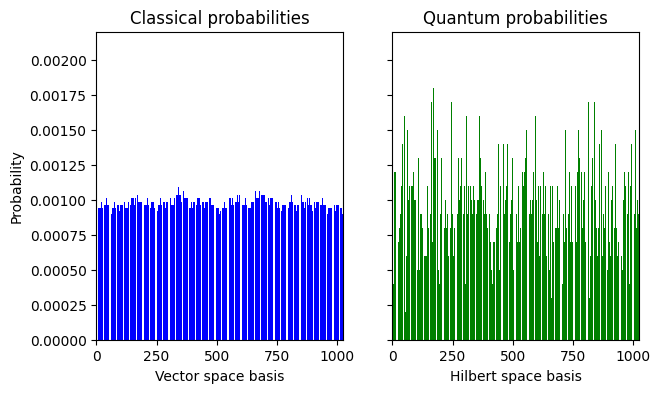

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4), sharey=True)

ax1.bar(np.arange(0, 2 ** n_qubits), probs_exact, color="blue")
ax1.set_xlim(-0.5, 2 ** n_qubits - 0.5)
ax1.set_xlabel("Vector space basis")
ax1.set_ylabel("Probability")
ax1.set_title("Classical probabilities")

ax2.bar(np.arange(0, 2 ** n_qubits), statevector, color="green")
ax2.set_xlim(-0.5, 2 ** n_qubits - 0.5)
ax2.set_xlabel("Hilbert space basis")
ax2.set_title("Quantum probabilities")

plt.show()